In [1]:
import sqlalchemy
import pymysql
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

df = pd.read_csv("../data/cleaned_food_delivery_data.csv")

connection_url = URL.create(
    "mysql+pymysql",
    username="root",
    password="apple",
    host="localhost",
    port=3306,
    database="online_food_delivery"

    )

engine = create_engine(connection_url)

with engine.connect() as connection:
    print("Connected to online_food_delivery database!")

Connected to online_food_delivery database!


In [3]:
print("DataFrame rows:", len(df))

DataFrame rows: 100000


# Analyst Tasks (EDA & Analytics)

## Customer & Order Analysis

In [4]:
# 1.Identify top-spending customers
query = """
SELECT Customer_ID, COUNT(Order_ID) AS Total_Orders, SUM(Final_Amount) AS Total_Spending FROM orders 
GROUP BY Customer_ID
ORDER BY Total_Spending DESC
LIMIT 10;
"""

top_customers = pd.read_sql(query, engine)

top_customers

,Customer_ID,Total_Orders,Total_Spending
0,CUST5267,20,51827.0
1,CUST1606,20,51171.0
2,CUST6706,18,47389.0
3,CUST6252,20,45925.0
4,CUST5534,20,45218.0
5,CUST1239,22,44983.0
6,CUST6457,20,44401.0
7,CUST4431,23,44335.0
8,CUST1968,18,44281.0
9,CUST6293,21,44211.0


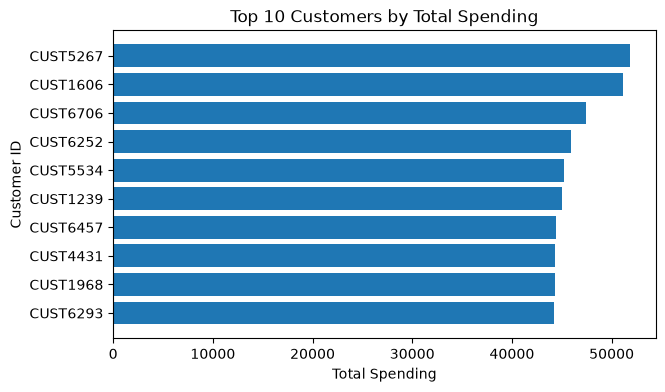

In [5]:
plt.figure(figsize=(7, 4))

plt.barh(
    top_customers["Customer_ID"],
    top_customers["Total_Spending"]
)

plt.title("Top 10 Customers by Total Spending")
plt.xlabel("Total Spending")
plt.ylabel("Customer ID")

plt.gca().invert_yaxis()

plt.show()

### Insights 
The analysis shows the top 10 customers based on their total spending. CUST5267 spent the most, with ₹51,827 across 20 orders, followed by CUST1606 with ₹51,171 from 20 orders. Overall, the top customers placed 18–23 orders, showing that higher spending is mainly driven by both frequent orders and higher order values.

In [6]:
# 2. Analyze age group vs order value
query = """
SELECT Customer_Age_Group, COUNT(Order_ID) AS Total_Orders, AVG(Order_Value) AS Average_Order_Value
FROM orders
GROUP BY Customer_Age_Group
ORDER BY Average_Order_Value DESC;
"""

age_order_value = pd.read_sql(query, engine)

age_order_value

,Customer_Age_Group,Total_Orders,Average_Order_Value
0,Adult,11653,1806.888441
1,Senior,11492,1784.602071
2,Middle Age,67609,1784.536970
3,Young Adult,9246,1782.305970


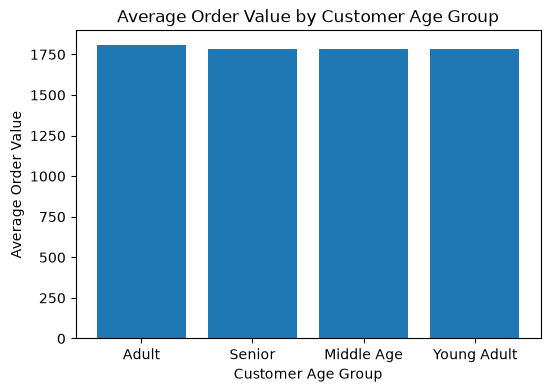

In [37]:
plt.figure(figsize=(6, 4))

plt.bar(
    age_order_value["Customer_Age_Group"],
    age_order_value["Average_Order_Value"]
)

plt.title("Average Order Value by Customer Age Group")
plt.xlabel("Customer Age Group")
plt.ylabel("Average Order Value")

plt.xticks(rotation=0)

plt.show()

### Insights 
The Adult customer group has the highest average order value at ₹1,806.89. The other age groups—Senior, Middle Age, and Young Adult—have very similar average order values, ranging from ₹1,782 to ₹1,785. Overall, age has only a small impact on the average order value.

In [8]:
# 3. Weekend vs weekday order patterns
query = """
SELECT Order_Day, COUNT(Order_ID) AS Total_Orders
FROM orders
GROUP BY Order_Day
ORDER BY Total_Orders DESC;
"""

weekend_weekday = pd.read_sql(query, engine)

weekend_weekday

,Order_Day,Total_Orders
0,Weekday,71370
1,Weekend,28630


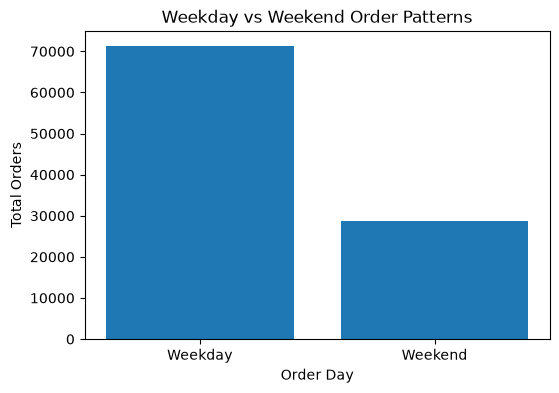

In [9]:
plt.figure(figsize=(6, 4))

plt.bar(
    weekend_weekday["Order_Day"],
    weekend_weekday["Total_Orders"]
)

plt.title("Weekday vs Weekend Order Patterns")
plt.xlabel("Order Day")
plt.ylabel("Total Orders")

plt.show()

### Insights 
The analysis shows that 71,370 orders were placed on weekdays, compared with 28,630 orders on weekends. This indicates that customers placed significantly more orders during weekdays than on weekends.

## Revenue & Profit Analysis

In [10]:
# Monthly revenue trends
query = """
SELECT
    DATE_FORMAT(Order_Date, '%%Y-%%m') AS Month,
    SUM(Final_Amount) AS Total_Revenue
FROM orders
WHERE Order_Date IS NOT NULL
GROUP BY DATE_FORMAT(Order_Date, '%%Y-%%m')
ORDER BY Month;
"""

monthly_revenue = pd.read_sql(query, engine)

monthly_revenue

,Month,Total_Revenue
0,2024-01,14481750.0
1,2024-02,13401111.0
2,2024-03,14181215.0
3,2024-04,13769030.0
4,2024-05,14208417.0
5,2024-06,13954100.0
6,2024-07,14646016.0
7,2024-08,14049879.0
8,2024-09,14091960.0
9,2024-10,14004558.0


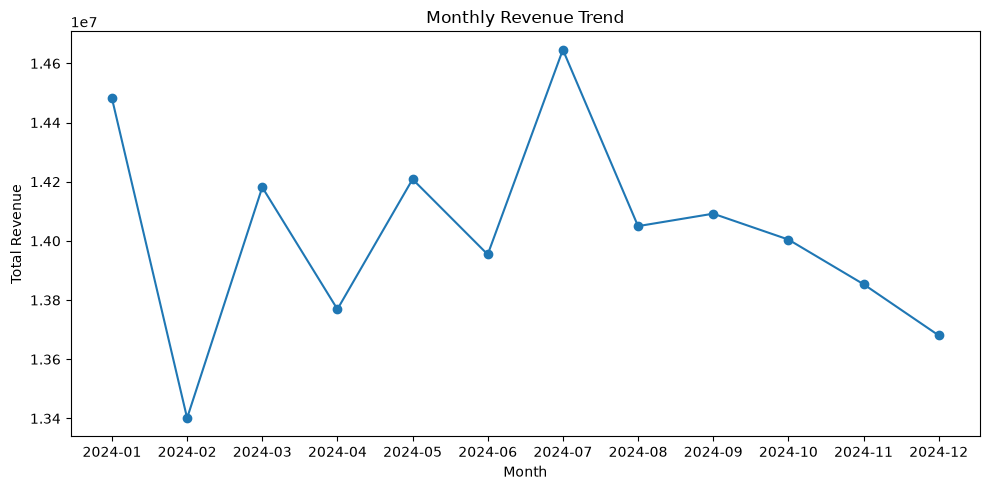

In [38]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_revenue["Month"],
    monthly_revenue["Total_Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Insights 
Monthly revenue fluctuated throughout 2024 without showing a consistent upward or downward trend. January recorded the highest revenue at ₹14.48 million**, while February had the lowest at ₹13.40 million. Overall, revenue stayed within a relatively narrow range, indicating fairly stable monthly revenue throughout the year.

In [12]:
# Impact of Discounts on Profit
query = """
SELECT
    CASE
        WHEN Discount_Applied = 0 THEN 'No Discount'
        WHEN Discount_Applied <= 50 THEN 'Low Discount'
        WHEN Discount_Applied <= 100 THEN 'Medium Discount'
        ELSE 'High Discount'
    END AS Discount_Category,
    COUNT(Order_ID) AS Total_Orders,
    ROUND(AVG(Discount_Applied), 2) AS Average_Discount,
    ROUND(AVG(Profit_Margin), 2) AS Average_Profit_Margin
FROM orders
GROUP BY Discount_Category
ORDER BY Average_Discount;
"""

discount_profit = pd.read_sql(query, engine)

discount_profit

,Discount_Category,Total_Orders,Average_Discount,Average_Profit_Margin
0,No Discount,16650,0.00,0.15
1,Low Discount,49974,40.05,0.15
2,Medium Discount,16776,100.00,0.15
3,High Discount,16600,300.00,0.15


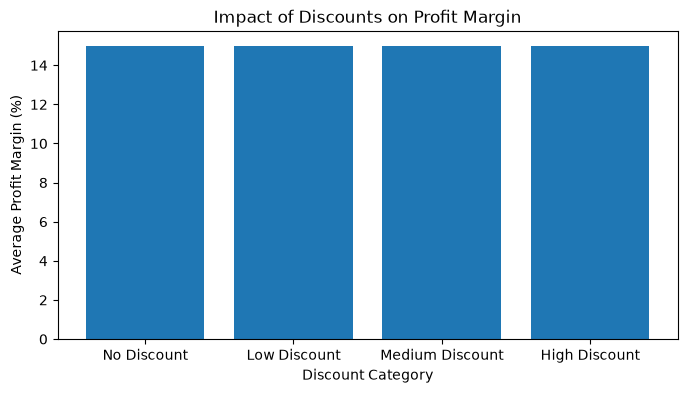

In [13]:
plt.figure(figsize=(8, 4))

plt.bar(
    discount_profit["Discount_Category"],
    discount_profit["Average_Profit_Margin"] * 100
)

plt.title("Impact of Discounts on Profit Margin")
plt.xlabel("Discount Category")
plt.ylabel("Average Profit Margin (%)")

plt.show()

### Insights 
The analysis shows that the average profit margin remains at 15% across all discount categories, from no discount to high discount. Therefore, within this dataset, the average profit margin does not vary across the defined discount levels. The number of orders differs between categories, with low-discount orders had the highest number of orders.

In [ ]:
# High-Revenue Cities 
query = """
SELECT
    City,
    COUNT(Order_ID) AS Total_Orders,
    SUM(Final_Amount) AS Total_Revenue
FROM orders
WHERE City <> 'Unknown'
GROUP BY City
ORDER BY Total_Revenue DESC;
"""

city_revenue = pd.read_sql(query, engine)

city_revenue

,City,Total_Orders,Total_Revenue
0,Bangalore,16732,28640669.0
1,Hyderabad,16884,28524579.0
2,Delhi,16695,28247386.0
3,Chennai,16470,28130481.0
4,Mumbai,16493,28003444.0


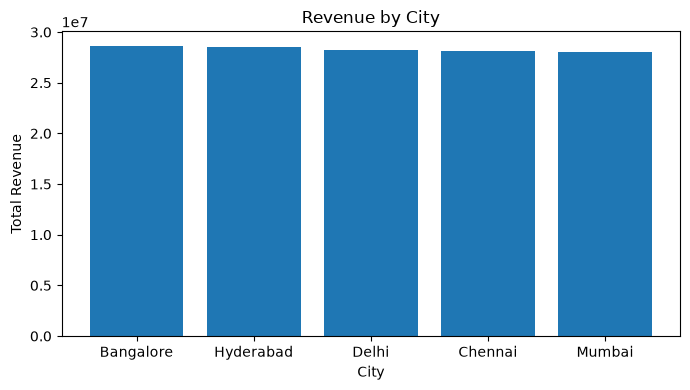

In [39]:
plt.figure(figsize=(7, 4))

plt.bar(
    city_revenue["City"],
    city_revenue["Total_Revenue"]
)

plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Total Revenue")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Insights 
Among the known cities, Bangalore generated the highest revenue at ₹28.64 million, closely followed by Hyderabad at ₹28.52 million. Mumbai recorded the lowest revenue among the five cities at ₹28.00 million.

In [ ]:
#High-revenue cuisines
query = """
SELECT
    Cuisine_Type,
    COUNT(Order_ID) AS Total_Orders,
    SUM(Final_Amount) AS Total_Revenue
FROM orders
WHERE Cuisine_Type <> 'Unknown'
GROUP BY Cuisine_Type
ORDER BY Total_Revenue DESC;
"""

cuisine_revenue = pd.read_sql(query, engine)

cuisine_revenue

,Cuisine_Type,Total_Orders,Total_Revenue
0,Indian,16685,28504452.0
1,Mexican,16602,28330767.0
2,Chinese,16651,28317523.0
3,Arabian,16658,28039302.0
4,Italian,16519,27940922.0


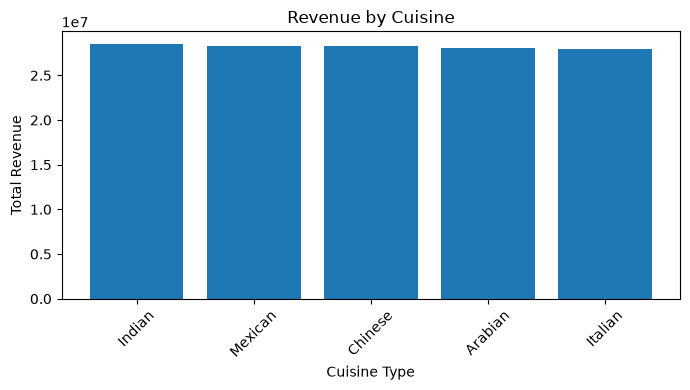

In [17]:
plt.figure(figsize=(7, 4))

plt.bar(
    cuisine_revenue["Cuisine_Type"],
    cuisine_revenue["Total_Revenue"]
)

plt.title("Revenue by Cuisine")
plt.xlabel("Cuisine Type")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Insights

For cuisine types, Indian cuisine generated the highest revenue at ₹28.50 million, while Italian cuisine recorded the lowest at ₹27.94 million. Overall, revenue was fairly evenly distributed across both cities and cuisine types, with only small differences between them.

## Delivery Performance

In [18]:
# Average Delivery Time by City
query = """
SELECT
    City,
    COUNT(Order_ID) AS Total_Orders,
    ROUND(AVG(Delivery_Time_Min), 2) AS Average_Delivery_Time
FROM orders
WHERE City <> 'Unknown'
GROUP BY City
ORDER BY Average_Delivery_Time DESC;
"""

city_delivery_time = pd.read_sql(query, engine)

city_delivery_time

,City,Total_Orders,Average_Delivery_Time
0,Mumbai,16493,125.94
1,Hyderabad,16884,125.03
2,Delhi,16695,124.90
3,Chennai,16470,124.55
4,Bangalore,16732,124.37


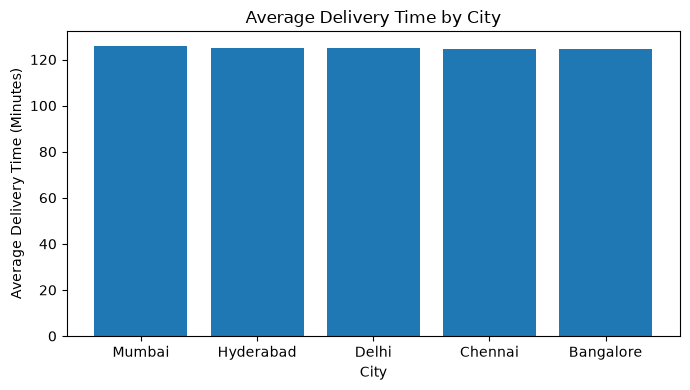

In [40]:
plt.figure(figsize=(7, 4))

plt.bar(
    city_delivery_time["City"],
    city_delivery_time["Average_Delivery_Time"]
)

plt.title("Average Delivery Time by City")
plt.xlabel("City")
plt.ylabel("Average Delivery Time (Minutes)")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Insights
The analysis shows that average delivery times are very similar across all five cities. Mumbai had the highest average delivery time at 125.94 minutes, while Bangalore had the lowest at 124.37 minutes. The difference of only 1.57 minutes suggests that delivery times vary very little between the cities analyzed.

In [20]:
# Distance vs Delivery Delay Analysis
query = """
SELECT
    CASE
        WHEN Distance_km <= 5 THEN '0-5 km'
        WHEN Distance_km <= 10 THEN '5-10 km'
        WHEN Distance_km <= 20 THEN '10-20 km'
        ELSE '20+ km'
    END AS Distance_Range,
    COUNT(Order_ID) AS Total_Orders,
    ROUND(AVG(Delivery_Time_Min), 2) AS Average_Delivery_Time
FROM orders
GROUP BY Distance_Range
ORDER BY
    CASE
        WHEN Distance_Range = '0-5 km' THEN 1
        WHEN Distance_Range = '5-10 km' THEN 2
        WHEN Distance_Range = '10-20 km' THEN 3
        ELSE 4
    END;
"""

distance_delivery = pd.read_sql(query, engine)

distance_delivery

,Distance_Range,Total_Orders,Average_Delivery_Time
0,0-5 km,14857,124.48
1,5-10 km,52001,124.92
2,10-20 km,6646,125.52
3,20+ km,26496,125.25


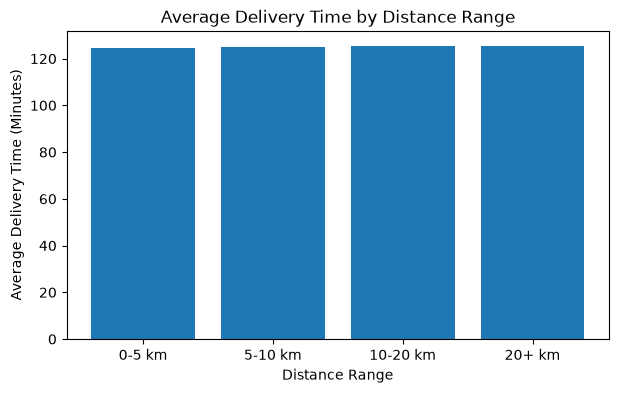

In [21]:
plt.figure(figsize=(7, 4))

plt.bar(
    distance_delivery["Distance_Range"],
    distance_delivery["Average_Delivery_Time"]
)

plt.title("Average Delivery Time by Distance Range")
plt.xlabel("Distance Range")
plt.ylabel("Average Delivery Time (Minutes)")

plt.show()

### Insights
The analysis shows that average delivery time remains fairly consistent across different distance ranges. Orders within 0–5 km had an average delivery time of 124.48 minutes, while the 10–20 km range recorded the highest at 125.52 minutes. Orders above 20 km averaged 125.25 minutes. Overall, the small differences suggest that distance alone has a limited impact on delivery time in this dataset.

In [22]:
# Delivery Rating vs Delivery Time
query = """
SELECT
    Delivery_Rating,
    COUNT(Order_ID) AS Total_Orders,
    ROUND(AVG(Delivery_Time_Min), 2) AS Average_Delivery_Time
FROM orders
WHERE Delivery_Rating IS NOT NULL
GROUP BY Delivery_Rating
ORDER BY Delivery_Rating;
"""

rating_delivery = pd.read_sql(query, engine)

rating_delivery

,Delivery_Rating,Total_Orders,Average_Delivery_Time
0,1.0,14292,125.05
1,2.0,14377,124.64
2,3.0,27913,124.54
3,4.0,14375,126.00
4,5.0,14007,125.07


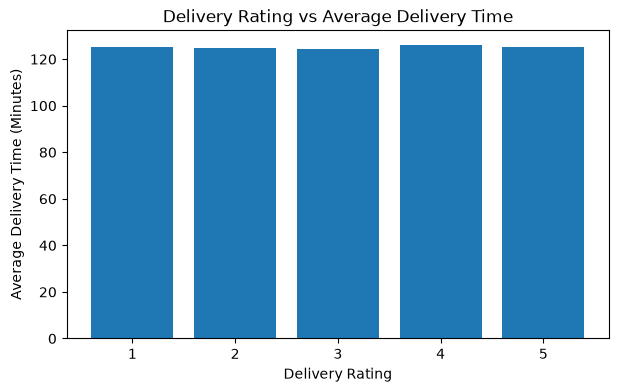

In [23]:
plt.figure(figsize=(7, 4))

plt.bar(
    rating_delivery["Delivery_Rating"],
    rating_delivery["Average_Delivery_Time"]
)

plt.title("Delivery Rating vs Average Delivery Time")
plt.xlabel("Delivery Rating")
plt.ylabel("Average Delivery Time (Minutes)")

plt.show()

### Insights
The analysis shows that average delivery time is fairly consistent across all delivery rating levels. Customers who gave a rating of 4 experienced the highest average delivery time at 126.00 minutes, while rating 3 had the lowest at 124.54 minutes. With a difference of only 1.46 minutes, the results suggest that delivery time alone has a limited relationship with customer delivery ratings** in this dataset.

## Restaurant Performance

In [24]:
# Top-Rated Restaurants
query = """
SELECT
    Restaurant_Name,
    COUNT(Order_ID) AS Total_Orders,
    ROUND(AVG(Restaurant_Rating), 2) AS Average_Rating
FROM orders
GROUP BY Restaurant_Name
ORDER BY Average_Rating DESC, Total_Orders DESC
LIMIT 10;
"""

top_restaurants = pd.read_sql(query, engine)

top_restaurants

,Restaurant_Name,Total_Orders,Average_Rating
0,Restaurant_101,178,4.33
1,Restaurant_1,193,4.31
2,Restaurant_162,182,4.31
3,Restaurant_209,212,4.30
4,Restaurant_496,203,4.30
5,Restaurant_481,190,4.30
6,Restaurant_355,181,4.30
7,Restaurant_234,225,4.29
8,Restaurant_105,213,4.29
9,Restaurant_395,212,4.29


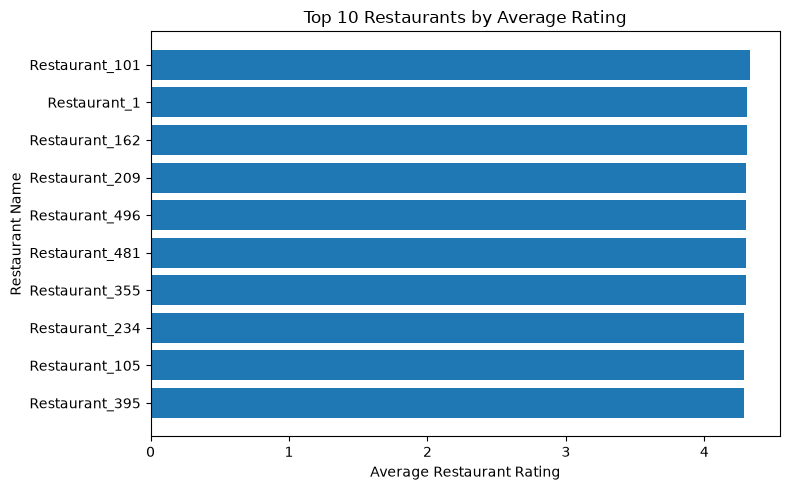

In [25]:
plt.figure(figsize=(8, 5))

plt.barh(
    top_restaurants["Restaurant_Name"],
    top_restaurants["Average_Rating"]
)

plt.title("Top 10 Restaurants by Average Rating")
plt.xlabel("Average Restaurant Rating")
plt.ylabel("Restaurant Name")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Insights
The analysis identifies the top 10 restaurants based on their average customer ratings. Restaurant_101 had the highest average rating of 4.33 across 178 orders, followed by Restaurant_1 and Restaurant_162, both with an average rating of 4.31. Overall, the top 10 restaurants had ratings between 4.29 and 4.33, showing only small differences in customer ratings. Each restaurant also had 178–225 orders, providing a reasonable order volume for comparison.

In [26]:
# Cancellation Rate by Restaurant
query = """
SELECT
    Restaurant_Name,
    COUNT(Order_ID) AS Total_Orders,
    SUM(CASE
        WHEN Order_Status = 'Cancelled' THEN 1
        ELSE 0
    END) AS Cancelled_Orders,
    ROUND(
        SUM(CASE
            WHEN Order_Status = 'Cancelled' THEN 1
            ELSE 0
        END) * 100.0 / COUNT(Order_ID),
        2
    ) AS Cancellation_Rate
FROM orders
GROUP BY Restaurant_Name
HAVING COUNT(Order_ID) >= 100
ORDER BY Cancellation_Rate DESC
LIMIT 10;
"""

restaurant_cancellation = pd.read_sql(query, engine)

restaurant_cancellation

,Restaurant_Name,Total_Orders,Cancelled_Orders,Cancellation_Rate
0,Restaurant_391,196,43.0,21.94
1,Restaurant_390,201,44.0,21.89
2,Restaurant_477,176,38.0,21.59
3,Restaurant_202,204,44.0,21.57
4,Restaurant_373,191,41.0,21.47
5,Restaurant_426,212,45.0,21.23
6,Restaurant_299,194,41.0,21.13
7,Restaurant_455,180,38.0,21.11
8,Restaurant_113,205,43.0,20.98
9,Restaurant_232,177,37.0,20.90


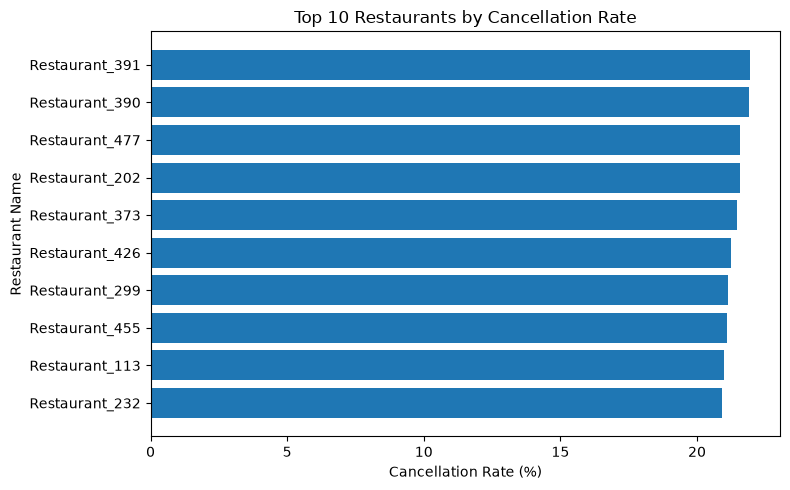

In [27]:
plt.figure(figsize=(8, 5))

plt.barh(
    restaurant_cancellation["Restaurant_Name"],
    restaurant_cancellation["Cancellation_Rate"]
)

plt.title("Top 10 Restaurants by Cancellation Rate")
plt.xlabel("Cancellation Rate (%)")
plt.ylabel("Restaurant Name")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Insights
The analysis identifies the 10 restaurants with the highest cancellation rates among those with at least 100 orders. Restaurant_391 had the highest cancellation rate at 21.94%, with 43 cancellations out of 196 orders, followed closely by Restaurant_390 at 21.89%. Overall, the cancellation rates ranged from 20.90% to 21.94%, showing only a small difference between the restaurants.

In [28]:
# Cuisine-wise Performance

query = """
SELECT
    Cuisine_Type,
    COUNT(Order_ID) AS Total_Orders,
    ROUND(AVG(Order_Value), 2) AS Average_Order_Value,
    ROUND(AVG(Restaurant_Rating), 2) AS Average_Restaurant_Rating,
    ROUND(AVG(Profit_Margin) * 100, 2) AS Average_Profit_Margin
FROM orders
WHERE Cuisine_Type <> 'Unknown'
GROUP BY Cuisine_Type
ORDER BY Average_Order_Value DESC;
"""

cuisine_performance = pd.read_sql(query, engine)

cuisine_performance

,Cuisine_Type,Total_Orders,Average_Order_Value,Average_Restaurant_Rating,Average_Profit_Margin
0,Indian,16685,1795.81,4.20,14.92
1,Mexican,16602,1792.86,4.20,15.11
2,Chinese,16651,1787.15,4.19,14.93
3,Italian,16519,1778.29,4.21,15.16
4,Arabian,16658,1769.79,4.20,15.11


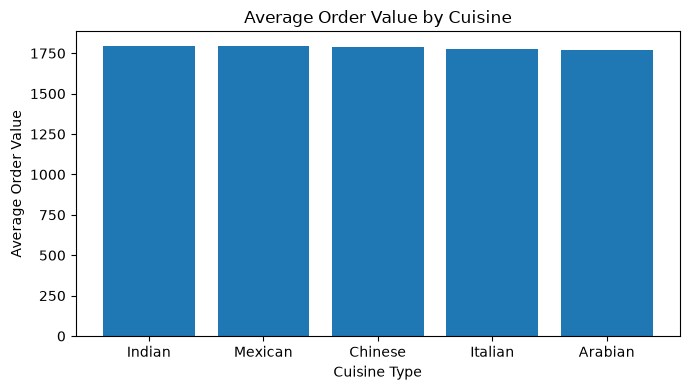

In [29]:
plt.figure(figsize=(7, 4))

plt.bar(
    cuisine_performance["Cuisine_Type"],
    cuisine_performance["Average_Order_Value"]
)

plt.title("Average Order Value by Cuisine")
plt.xlabel("Cuisine Type")
plt.ylabel("Average Order Value")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Insights
The analysis shows that performance is fairly consistent across the different cuisine types. Indian cuisine had the highest average order value at ₹1,795.81, while Arabian cuisine had the lowest at ₹1,769.79. Average restaurant ratings were also similar, ranging from 4.19 to 4.21, while average profit margins ranged from 14.92% to 15.16%. Overall, the small differences indicate fairly consistent performance across the analyzed cuisine categories.

In [30]:
# Peak Hour Demand Analysis
query = """
SELECT
    Peak_Hour,
    COUNT(Order_ID) AS Total_Orders
FROM orders
GROUP BY Peak_Hour
ORDER BY Total_Orders DESC;
"""

peak_hour_demand = pd.read_sql(query, engine)

peak_hour_demand

,Peak_Hour,Total_Orders
0,Non-Peak Hour,33585
1,Peak Hour,33453
2,Unknown,32962


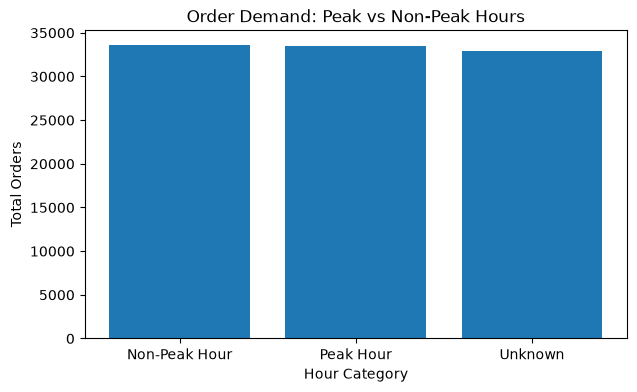

In [31]:
plt.figure(figsize=(7, 4))

plt.bar(
    peak_hour_demand["Peak_Hour"],
    peak_hour_demand["Total_Orders"]
)

plt.title("Order Demand: Peak vs Non-Peak Hours")
plt.xlabel("Hour Category")
plt.ylabel("Total Orders")

plt.show()

### Insights
The analysis shows that order demand is almost evenly split between peak and non-peak hours. Non-peak hours recorded 33,585 orders, while peak hours recorded 33,453 orders, a difference of just 132 orders. Another 32,962 orders had no peak-hour classification. Overall, among orders with a known classification, demand is nearly the same during peak and non-peak periods.

In [32]:
# Payment Mode Preferences
query = """
SELECT
    Payment_Mode,
    COUNT(Order_ID) AS Total_Orders,
    ROUND(
        COUNT(Order_ID) * 100.0 / (SELECT COUNT(*) FROM orders),
        2
    ) AS Order_Percentage
FROM orders
GROUP BY Payment_Mode
ORDER BY Total_Orders DESC;
"""

payment_mode = pd.read_sql(query, engine)

payment_mode

,Payment_Mode,Total_Orders,Order_Percentage
0,Card,20094,20.09
1,Wallet,20086,20.09
2,COD,19977,19.98
3,UPI,19932,19.93
4,Unknown,19911,19.91


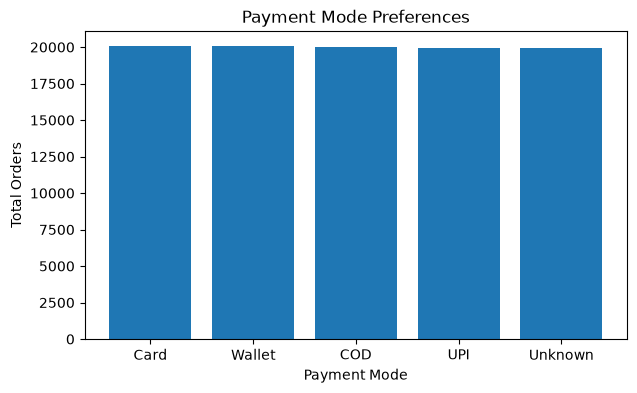

In [33]:
plt.figure(figsize=(7, 4))

plt.bar(
    payment_mode["Payment_Mode"],
    payment_mode["Total_Orders"]
)

plt.title("Payment Mode Preferences")
plt.xlabel("Payment Mode")
plt.ylabel("Total Orders")

plt.show()

### Insights
The analysis shows that payment usage is almost evenly distributed across the available payment modes. Card had the highest number of orders with 20,094 (20.09%), closely followed by Wallet with 20,086 (20.09%). COD accounted for 19,977 orders (19.98%), while UPI had 19,932 orders (19.93%). Another 19,911 orders (19.91%) had an unknown payment mode. Overall, all known payment modes were used at very similar levels in the dataset.

In [34]:
# Cancellation Reason Analysis

query = """
SELECT
    Cancellation_Reason,
    COUNT(Order_ID) AS Cancelled_Orders,
    ROUND(
        COUNT(Order_ID) * 100.0 /
        (
            SELECT COUNT(*)
            FROM orders
            WHERE Order_Status = 'Cancelled'
              AND Cancellation_Reason <> 'Unknown'
        ),
        2
    ) AS Cancellation_Percentage
FROM orders
WHERE Order_Status = 'Cancelled'
  AND Cancellation_Reason <> 'Unknown'
GROUP BY Cancellation_Reason
ORDER BY Cancelled_Orders DESC;
"""

cancellation_reason = pd.read_sql(query, engine)

cancellation_reason

,Cancellation_Reason,Cancelled_Orders,Cancellation_Percentage
0,Late Delivery,3059,33.87
1,Customer Cancelled,2993,33.14
2,Restaurant Issue,2979,32.99


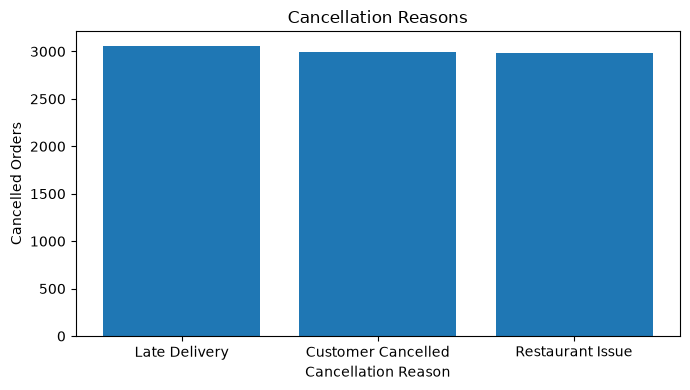

In [36]:
plt.figure(figsize=(7, 4))

plt.bar(
    cancellation_reason["Cancellation_Reason"],
    cancellation_reason["Cancelled_Orders"]
)

plt.title("Cancellation Reasons")
plt.xlabel("Cancellation Reason")
plt.ylabel("Cancelled Orders")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Insights
The analysis shows that the three known cancellation reasons are almost evenly distributed. Late Delivery accounted for 3,059 cancellations (33.87%), followed by Customer Cancelled with 2,993 (33.14%) and Restaurant Issue with 2,979 (32.99%). Overall, cancellations are spread fairly evenly across delivery, customer, and restaurant-related reasons, rather than being concentrated in one category.